# HW9 Key Part I - writing part (50 pts)

see calculation at the top of page 25 of notes.

**Grading rubric:**
- Derivations of the 3 gradients are correct (30 pts)
- Must be able to trace back the code written in Part II (or pseudocode) to the calculations in Part I (20 pts).

# HW9 Key Part II - notebook part (50 pts)

Grading rubric:
- Code need to be coherent and understandable.
- `NN_clf()`: 20 pts
- `NN_clf_pred()`: 10 pts
- other necessary exercution and testing error display where successful training has been demonstrated: 20 pts

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_gaussian_quantiles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
N = 500
X, y = make_gaussian_quantiles(mean = None, cov = 0.5, n_samples = N, 
                               n_features = 2, n_classes = 2, shuffle = True, 
                               random_state = 42)

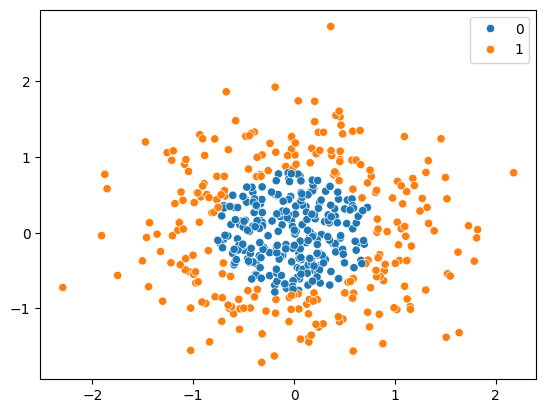

In [3]:
sns.scatterplot(x = X[:,0], 
                y = X[:,1], 
                hue = y,
                );

## Define some functions

In [4]:
def relu(x):
    # relu function
    return np.maximum(x, 0)

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [75]:
def ce_J(s, y):
    '''Cross Entropy Function
    '''
    # both s, y are made column vectors
    s = s.reshape([-1, 1])
    y = s.reshape([-1, 1])
    N = len(s)
    # clipping is for stability
    epsilon = 1e-15
    s_clipped = np.clip(s, epsilon, 1 - epsilon)
    # s_clipped willl stay at least epsilon away from 0 or 1
    return - (np.sum(y*np.log(s_clipped) + (1-y)*np.log(1-s_clipped)))/N

## Train test split as outlined in HW9 starter file

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 45)

## `NN_clf()` function as requested

In [71]:
def NN_clf(X, y, hidden_size = 5, seed = 3, lr = 1e-1, max_iter = 100):
    n, p = X.shape

    # size (number of nodes) of hidden layer
    p1 = hidden_size
    
    # turn y into a column
    y = y.reshape([-1, 1])
    
    # initialization
    np.random.seed(seed)
    W1 = np.random.randn(p, p1) # shape is p by p1
    W2 = np.random.randn(p1, 1)
    b = np.random.randn(1, p1)
    b2 = np.random.randn(1, 1)
    
    for i in range(max_iter):
        # forward propargation
        u1 = X@W1 + b
        h = relu(u1)
        u2 = h@W2 + b2
        s = sigmoid(u2)
    
        # compute cost
        J = ce_J(s, y)
    
        # backward propagation for computing gradient 
        #ds = -1/n*(y/s - (1-y)/(1-s))    
        #s_prime_u2 = s*(1-s)
        #du2 = ds*s_prime_u2
        du2 = -1/n*(y - s)
        dW2 = (h.T)@du2
    
        dh = du2@W2.T
        du1 = dh*relu(np.sign(u1))
        dW1 = X.T@du1
    
        db = np.sum(du1, axis = 0)
        db2 = np.sum(du2)
        
        # gradient descent
        W1 = W1 - lr * dW1
        W2 = W2 - lr * dW2
        b = b - lr * db
        b2 = b2 - lr * db2
        
    theta = (W1, W2, b, b2)
    return theta, J

## `NN_clf_pred()` function as requested

In [72]:
def NN_clf_pred(X, theta_trained):
    # X is new data
    # unpack theta_trained
    W1, W2, b, b2 = theta_trained
    
    u1 = X@W1 + b
    h = relu(u1)
    u2 = h@W2 + b2
    s = sigmoid(u2)
    return s

I added a `NN_clf_pred_class()` function which turns s to binary.

- if s > 0.5, then it becomes 1
- if s <= 0.5, then it becomes 0

In [9]:
def NN_clf_pred_class(X, theta_trained):
    s = NN_clf_pred(X, theta_trained)
    return (s > 0.5).astype(int)

## Training

In [79]:
theta_trained, J = NN_clf(X_train, y_train, hidden_size = 6, lr = 1e0, max_iter = 5000)
f"The training cost is {J:.4f}"

'The training cost is 0.0241'

## Displaying test error

In [80]:
y_pred = NN_clf_pred(X_test, theta_trained)
f"testing error is {ce_J(y_pred, y_test):.4f}"

'testing error is 0.0537'

In [81]:
y_pred_01 = NN_clf_pred_class(X_test, theta_trained)
accuracy_score(y_test, y_pred_01)

0.98

**This means that our model is able to assign 98% of the testing points to the correct class.**